In [1]:
## 오늘은 분류모델입니다.
## 분류 모델 중에.. 로지스틱회귀 모델입니다.
## 로지스틱회귀라는 이름으로 회귀모델이라고 생각할 수 있지만
## 이름만 회귀가 붙은 뿐, 분류 모델입니다.

In [34]:
## 데이터 로드
## 교사용 컴퓨터에 오늘 날짜에 있어요. 그거 붙여넣기 해 주세요
import pandas as pd
import numpy as np

df = pd.DataFrame({

    # 사이트 방문 시간(분)
    "visit_time": [
        3,5,7,4,8,10,12,6,15,18,
        20,9,11,14,16,22,25,13,17,19,
        21,24,26,28,30,8,12,18,23,27,
        60,1,45,np.nan,50,2,35,np.nan,40,5,
        6,7,8,12,14,16,18,20,22,24,
        5,9,11,13,15,17,19,21,23,25,
        4,6,8,10,12,14,16,18,20,22,
        7,9,13,15,17,19,21,23,26,29,
        31,33,35,37,39,41,43,45,47,49,
        2,3,5,7,9,11,13,15,17,80
    ],

    # 조회한 상품 수
    "viewed_products": [
        2,3,4,2,5,6,7,3,8,9,
        10,4,5,6,7,11,12,5,8,9,
        10,11,13,14,15,4,6,8,10,12,
        40,1,30,35,np.nan,2,25,28,np.nan,3,
        4,5,6,7,8,9,10,11,12,13,
        3,4,5,6,7,8,9,10,11,12,
        2,3,4,5,6,7,8,9,10,11,
        4,5,7,8,9,10,11,12,14,15,
        16,17,18,19,20,21,22,23,24,25,
        1,2,3,4,5,6,7,8,9,50
    ],

    # 장바구니 담은 상품 수
    "cart_count": [
        0,0,1,0,-1,2,2,1,3,3,
        4,1,2,2,3,4,-1,2,3,4,
        4,5,5,6,6,1,2,3,4,5,
        15,0,12,np.nan,14,0,10,11,np.nan,1,
        1,1,2,2,3,3,-1,4,5,5,
        0,1,1,2,2,3,3,4,4,5,
        0,1,1,2,2,3,3,4,4,5,
        1,1,2,2,3,3,4,4,5,6,
        6,7,7,8,8,9,9,10,10,11,
        0,0,1,1,2,2,3,3,4,20
    ],

    # 이전 구매 여부
    "previous_purchase": [
        0,0,0,0,1,0,1,0,1,1,
        1,0,0,1,1,1,1,0,1,1,
        1,1,1,1,1,0,1,-1,1,1,
        1,0,1,1,np.nan,0,1,1,0,np.nan,
        0,0,1,1,1,1,1,1,1,1,
        0,0,0,1,1,1,1,1,1,1,
        0,0,1,1,1,1,1,1,1,1,
        0,1,1,1,1,1,1,1,1,1,
        1,1,1,1,1,1,-1,1,1,1,
        0,0,0,0,1,1,1,1,1,1
    ],

    # 쿠폰 사용 여부
    "coupon_used": [
        0,1,0,0,1,1,0,0,1,1,
        1,0,1,1,0,1,1,0,1,1,
        0,1,1,1,1,0,0,1,1,1,
        1,0,np.nan,1,1,0,1,np.nan,0,1,
        0,1,0,1,0,1,0,1,0,1,
        0,1,0,1,0,1,0,1,0,1,
        0,1,0,1,0,1,0,1,0,1,
        1,1,1,1,1,1,1,1,1,1,
        0,0,0,0,0,1,1,1,1,1,
        0,0,0,1,1,1,1,1,1,1
    ],

    # 모바일 접속 여부
    "mobile_access": [
        1,1,0,1,0,1,1,0,1,1,
        1,0,0,1,1,1,1,0,1,1,
        0,1,1,1,1,0,1,1,0,1,
        1,1,0,np.nan,1,0,1,1,np.nan,0,
        1,0,1,0,1,0,1,0,1,0,
        1,0,1,0,1,0,1,0,1,0,
        1,0,1,0,1,0,1,0,1,0,
        1,1,1,1,1,1,1,1,1,1,
        0,0,0,0,0,1,1,1,1,1,
        1,1,0,0,1,1,0,0,1,1
    ],

    # 리뷰 확인 횟수
    "review_check_count": [
        1,2,1,0,3,4,2,1,5,6,
        7,2,3,4,5,7,8,2,4,5,
        6,7,8,9,10,1,2,5,6,8,
        25,0,20,22,np.nan,1,18,19,np.nan,2,
        1,2,2,3,3,4,4,5,5,6,
        1,1,2,2,3,3,4,4,5,5,
        0,1,1,2,2,3,3,4,4,5,
        2,3,4,5,6,7,8,9,10,11,
        12,13,14,15,16,17,18,19,20,21,
        0,1,1,2,2,3,3,4,4,30
    ],

    # 구매 여부
    "purchase": [
        0,0,0,0,0,1,1,0,1,1,
        1,0,0,1,1,1,1,0,1,1,
        1,1,1,1,1,0,0,1,1,1,
        0,1,1,0,0,1,1,0,1,0,
        0,0,1,1,0,1,0,1,1,1,
        0,0,0,1,0,1,1,1,0,1,
        0,0,1,0,1,1,0,1,1,1,
        0,1,1,1,0,1,1,1,1,1,
        1,1,1,1,1,1,1,1,0,0,
        0,0,0,0,1,1,1,1,0,1
    ]

})

# print(df.head())
# print(df.isnull().sum())
# print(df.shape)

In [35]:
# 데이터 기본 정보 확인
print(df.shape) # 샘플데이터 100건, 샘플데이터는 피처가 8개

print(df.info())
# 데이터갯수  - 100
# 변수타입   - 모두다 숫자 
#             문자가 있다 > 1. 형변환   2. 원핫인코딩,라벨처리
# null여부 - 0-6인덱스의 피처는 널 의심

(100, 8)
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visit_time          98 non-null     float64
 1   viewed_products     98 non-null     float64
 2   cart_count          98 non-null     float64
 3   previous_purchase   98 non-null     float64
 4   coupon_used         98 non-null     float64
 5   mobile_access       98 non-null     float64
 6   review_check_count  98 non-null     float64
 7   purchase            100 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 6.4 KB
None


In [7]:
print(df.head())
# 피처이름
# 글자 깨진거 없는지
# 대략적인 데이터의 값..
# 장바구니 담은 상품의 수는 -가 될 수 없을거 같아.. <결측치라고 보자

   visit_time  viewed_products  cart_count  previous_purchase  coupon_used  \
0         3.0              2.0         0.0                0.0          0.0   
1         5.0              3.0         0.0                0.0          1.0   
2         7.0              4.0         1.0                0.0          0.0   
3         4.0              2.0         0.0                0.0          0.0   
4         8.0              5.0        -1.0                1.0          1.0   

   mobile_access  review_check_count  purchase  
0            1.0                 1.0         0  
1            1.0                 2.0         0  
2            0.0                 1.0         0  
3            1.0                 0.0         0  
4            0.0                 3.0         0  


In [ ]:
## - 값이 문제가 될거 같아.. 가설 생각한 상태
## - 값이 있는지 확인하기 위해서 만약 1000건이라면 다 뒤질 수 없다
## 어떻게 하면 확인이 가능할까?  답... 
print(df.describe())  # 수치 데이터만 통계
# 널 값이 의심되는 피처?
# 최소값, 최대값 체크해서 이상치가 의심되는 피처?
# 나머지는 참고용.
# 피처가 가지고 있는 데이터의 스케일 단위가 어느 정도 차이가 있는가?

       visit_time  viewed_products  cart_count  previous_purchase  \
count   98.000000        98.000000   98.000000          98.000000   
mean    19.234694        10.336735    3.734694           0.704082   
std     13.862953         8.404643    3.656800           0.501733   
min      1.000000         1.000000   -1.000000          -1.000000   
25%      9.000000         5.000000    1.000000           0.000000   
50%     16.500000         8.000000    3.000000           1.000000   
75%     24.000000        12.000000    5.000000           1.000000   
max     80.000000        50.000000   20.000000           1.000000   

       coupon_used  mobile_access  review_check_count    purchase  
count    98.000000      98.000000           98.000000  100.000000  
mean      0.622449       0.632653            6.234694    0.620000  
std       0.487267       0.484561            6.273494    0.487832  
min       0.000000       0.000000            0.000000    0.000000  
25%       0.000000       0.000000     

In [36]:
## 주제는 구매를 하겠는가? 안 하겠는가? > 분류 모델
## 우리가 알고 있는 모델은 
## 1. 회귀모델 - 선형회귀, 다항회귀, 다중회귀
## 2. 분류모델 - 로지스틱회귀, 결정트리, 부스팅

## 오늘은 분류모델을 개발...  로지스틱회귀 알고리즘을 선택**
## 태도는 회귀와 분류가 있는데 로지스틱회귀를 공부하고 다른것도 ?

## 회귀랑은 다른 부분.. 
## 정답의 분포..정답을 맞춰야 한다.
## 만약 정답이 하나만 있다면 학습이 될까요? 정답이 적당하게 고루있어야
## 좋은 데이터
print(df['purchase'].value_counts())
# 분석, 구매한 샘플이 62개, 구매하지 않은 샘플이 38개 
print(df['purchase'].value_counts(normalize=True))
# 분석하면 구매한 샘플이 더 많은데.. 그것도 약 1.4배 정도 
# 5:5가 좋다고 보는데. 약간 좀 치우쳤죠.. 참고.. 하자

## 회귀 모델을 평가할 때 어떻게 했죠? mse, rmse, r2
##            mse : 실제값과 예측값 평가, 잘 맞추나
##            r2 : 평균으로 맞추는 것과 모델을 사용하는

## 분류 모델을 평가할  때는 
# Accuracy : 예측한 값에서 정답의 비율  
# precision :  구매라고 예측한 것 중 실제 정답이 구매인 비율
# Recall : 실제 구매 정답 중에 찾아낸 비율.. 구매한 데이터를 못찾음
#       병원 암진단.. 실제 암인데.. 암을 찾아낸 비율..
#         40%라면 실제 암인 환자중에서 40%만 암으로 판별  
# F1-score :   precision와  Recall 균형

purchase
1    62
0    38
Name: count, dtype: int64
purchase
1    0.62
0    0.38
Name: proportion, dtype: float64


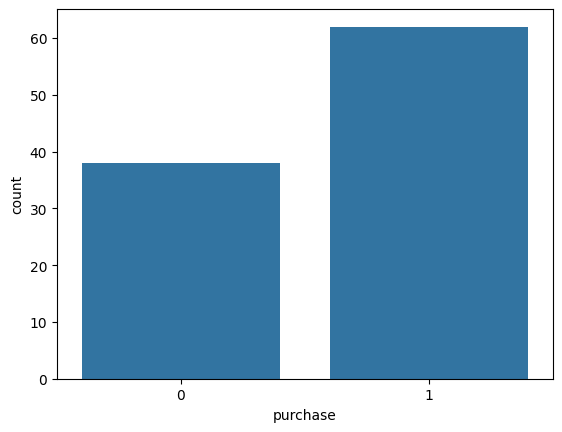

In [13]:
# 정답라벨을 시각화 
# 정답이라고 표현하지 않고 클래스..표현..
# 클래스.. 단어만 보고 문장 전체를 봅니다. 
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='purchase', data=df)
plt.show()

In [ ]:
# 여기서 중요한 것은 우리는 확인만 하는 중
# 이러는 이유? 먼저는 baseline을 만들 것이고
# 방금 확인 데이터의 특징을 여러 기법을 통해서 처리한 후
# baseline에 적용시켜서 최적의 모델을 만들려고 합니다.
# 그래서 확인만 한다.

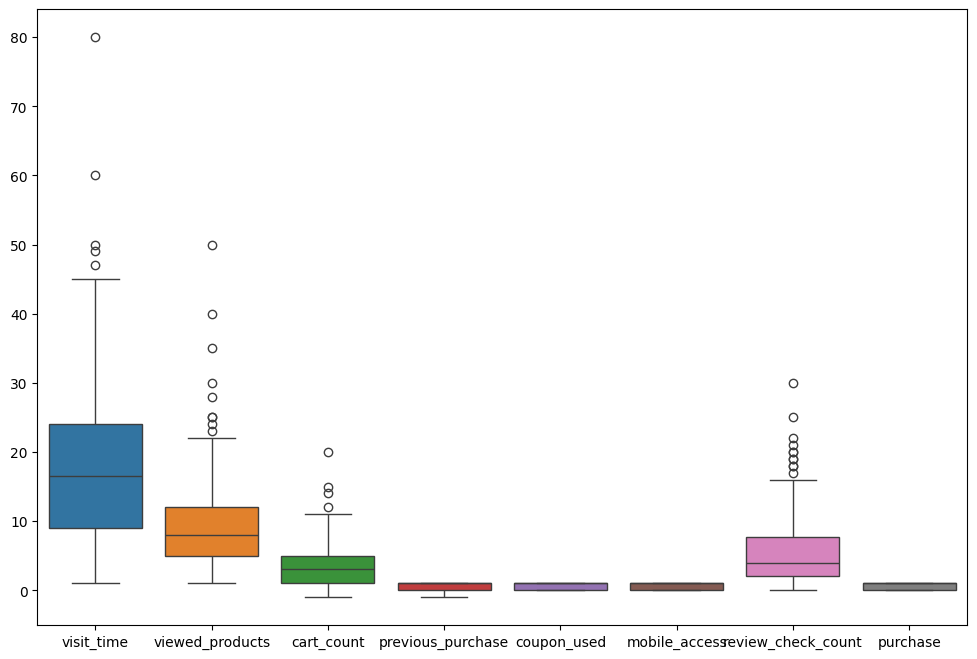

In [ ]:
# 계속 EDA  탐색 중
#  이번에는 이상치를 확인
# 이상치를 확인 하기 위한 시각화 > 박스플롯
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.show()

# 피처별 데이터 값의 범위 .. 
# 동그라미가 이상치...
# previous_purchase, coupon_used, mobile_access , purchase
# 위의 피처는 0과 1의 값만 같는다. 박스플롯으로 볼 의미는 없다.
# 본다면 0과 1이 아닌 다른 값이 있는지? 이상치

# 피처별로 최소값과 최대값의 단위가 별 차이 없다.. 그냥써도 된다.
# 이상치가 있는 피처가 4개가 있다.. 
# baseline은 그냥 처리안하겠다.. 
# 이유) visit_time은 김티처 처럼 고민하고 고민하고 또 고민하..
# 전략, 일단  baseline만들고 모든 피처 이상치 처리하던가. 골라서 하던가
# 테스트해 보자.. 


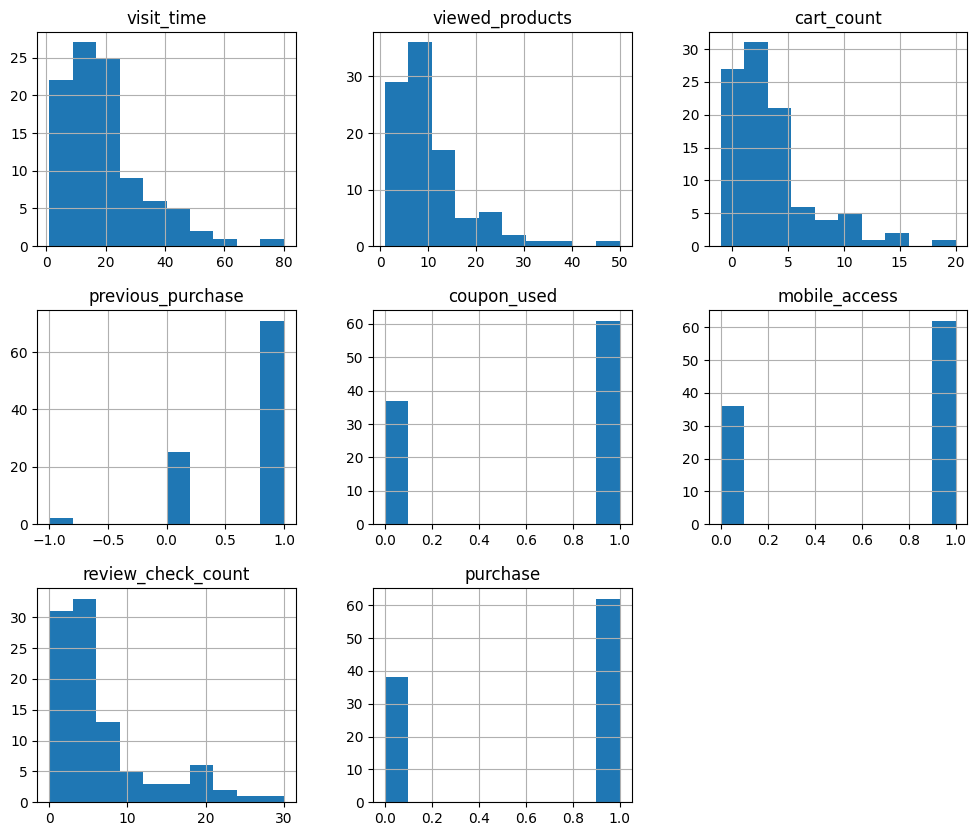

In [ ]:
# 변수 분포 확인 - 개인적인 견해.. 모델만들때는 그냥 참고용
df.hist(figsize=(12,10))
plt.show()

# 정상분포 그림이 성능이 제일 좋다고 합니다..
# visit_time은 왼쪽으로 쏠려 있고.. 
# 만약 정상분포를 억지로 만드려면 피처가 오염이 될 수 있다.
# 너무 크게 치우치지 않는다면 나중에 해석할 때 참고만 합니다.

In [ ]:
## 여기까지의 핵심은 데이터 이해.. 
## 데이터 이해는 어떤 모델을 개발하던 .. 선행이 되어야 합니다.
## 우리 아이는 잠이 많아.. 이 친구가 학교에 가면 선생님 참고 좀 부탁
## 우리 데이터는 이상치가 좀 있어.. 이 데이터로 모델을 만들면 ~

## 요약
## 1. 정답 데이터는 클래스가 불균형이다.. 
## 2. 일부 변수는 이상치가 있다.
## 3. -1일 값인데.. 실제 존재하지 않은 데이터이다.
## 4. 이상치나 데이터범위를 스케일링 처리를 해야 할 가능성도 있다.
## 5. 결측치를 처리할 가능성이 있다. 



In [37]:
# 결측치는 기본으로 처리를 해야 합니다. 
df.isnull().sum()

visit_time            2
viewed_products       2
cart_count            2
previous_purchase     2
coupon_used           2
mobile_access         2
review_check_count    2
purchase              0
dtype: int64

In [18]:
df.describe()


,visit_time,viewed_products,cart_count,previous_purchase,coupon_used,mobile_access,review_check_count,purchase
count,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,100.000000
mean,19.234694,10.336735,3.734694,0.704082,0.622449,0.632653,6.234694,0.620000
std,13.862953,8.404643,3.656800,0.501733,0.487267,0.484561,6.273494,0.487832
min,1.000000,1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,5.000000,1.000000,0.000000,0.000000,0.000000,2.000000,0.000000
50%,16.500000,8.000000,3.000000,1.000000,1.000000,1.000000,4.000000,1.000000
75%,24.000000,12.000000,5.000000,1.000000,1.000000,1.000000,7.750000,1.000000
max,80.000000,50.000000,20.000000,1.000000,1.000000,1.000000,30.000000,1.000000


In [38]:
# EDA탐색 결과 -1도 결측치로 볼 수 있다.
# null은 문자열 null과 넘파이 null이 있다. 
# 넘파이 null은 수치데이터 통계가 가능하다.. 

import numpy as np

columns_minus = ['cart_count','previous_purchase']
df[columns_minus]=df[columns_minus].mask(
    df[columns_minus] <0, np.nan    
)

In [39]:
print(df.isnull().sum())

visit_time            2
viewed_products       2
cart_count            5
previous_purchase     4
coupon_used           2
mobile_access         2
review_check_count    2
purchase              0
dtype: int64


In [40]:
df.isnull().sum()

visit_time            2
viewed_products       2
cart_count            5
previous_purchase     4
coupon_used           2
mobile_access         2
review_check_count    2
purchase              0
dtype: int64

In [41]:
### baseline모델을 만들자 
### baseline을 만들고 위에서 분석한 결과로 이상치 등을 처리한 모델과 비교

### 결측치만 처리하자.. 결측치를 처리 할때, 제거, 평균, 중앙값 
### 베이스 라인 중 이중에 평균으로 하자.
#0. 라이브러리
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#1. 데이터 준비
df2=df.copy()  ## df원본인데 복사해서 사용하려고 함.

#2. 결측치처리
df2.fillna(df2.mean(), inplace=True)
# print(df.isnull().sum())

#3. 입력피처, 타켓분리
X=df2.drop("purchase", axis=1)
y=df2['purchase']
#print(y)

#4. 데이터 셋 분리
X_train, X_test, y_train, y_test =train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
# print(X_train.shape)

#5. 모델생성 :  분류모델을 개발.. 이중에 로지스틱회귀를 분류 모델
model = LogisticRegression(max_iter=1000) #1000번 반복해서 공부해

#6. 모델학습
model.fit(X_train,y_train)

#7. 평가 (학습된 모델로 예측값을 가져오고, 실제 값하고 비교해서 )
pred = model.predict(X_test)
# 분류 평가. Accuracy, Precision, Recall, F1-score
print('Accuracy', accuracy_score(y_test, pred))
print('Precison', precision_score(y_test, pred))
print('Recall', recall_score(y_test, pred))
print('F1-score', f1_score(y_test, pred))

Accuracy 0.75
Precison 0.7142857142857143
Recall 0.9090909090909091
F1-score 0.8


In [ ]:
# Accuracy 0.75                예측값이 정답을 맞춘 비율
# Precison 0.7142857142857143  구매라고 예측한 것 중 실제 구매인 경우
# Recall 0.9090909090909091  정답은 구매인다.. 예측해서 맞춘 것 10% 놓침
# F1-score 0.8   Precison와 Recall의 균형이 80% 정도된다

# 평가..
# 최소 전처리만 해서 이정도 나쁘지 않다..
# 이상치를 처리하고 더 모델을 평가해 보자..
# 이 모델은 다른 전략을 추가하기 전의 베이스 모델이다.

In [43]:
df.isnull().sum()

visit_time            2
viewed_products       2
cart_count            5
previous_purchase     4
coupon_used           2
mobile_access         2
review_check_count    2
purchase              0
dtype: int64

In [44]:
# 베이스 모델에서 > 결측치를 중앙값으로 한다면?
#0. 라이브러리
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#1. 데이터 준비
df2=df.copy()  ## df원본인데 복사해서 사용하려고 함.

#2. 결측치처리
df2.fillna(df2.median(), inplace=True)
# print(df.isnull().sum())

#3. 입력피처, 타켓분리
X=df2.drop("purchase", axis=1)
y=df2['purchase']
#print(y)

#4. 데이터 셋 분리
X_train, X_test, y_train, y_test =train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
# print(X_train.shape)

#5. 모델생성 :  분류모델을 개발.. 이중에 로지스틱회귀를 분류 모델
model = LogisticRegression(max_iter=1000) #1000번 반복해서 공부해

#6. 모델학습
model.fit(X_train,y_train)

#7. 평가 (학습된 모델로 예측값을 가져오고, 실제 값하고 비교해서 )
pred = model.predict(X_test)
# 분류 평가. Accuracy, Precision, Recall, F1-score
print('Accuracy', accuracy_score(y_test, pred))
print('Precison', precision_score(y_test, pred))
print('Recall', recall_score(y_test, pred))
print('F1-score', f1_score(y_test, pred))

Accuracy 0.7
Precison 0.6666666666666666
Recall 0.9090909090909091
F1-score 0.7692307692307693


In [45]:
# 결측치를 제거
#0. 라이브러리
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#1. 데이터 준비
df2=df.copy()  ## df원본인데 복사해서 사용하려고 함.

#2. 결측치처리
df2=df2.dropna()
# print(df.isnull().sum())
print(df2.shape)

#3. 입력피처, 타켓분리
X=df2.drop("purchase", axis=1)
y=df2['purchase']

#4. 데이터 셋 분리
X_train, X_test, y_train, y_test =train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
# print(X_train.shape)

#5. 모델생성 :  분류모델을 개발.. 이중에 로지스틱회귀를 분류 모델
model = LogisticRegression(max_iter=1000) #1000번 반복해서 공부해

#6. 모델학습
model.fit(X_train,y_train)

#7. 평가 (학습된 모델로 예측값을 가져오고, 실제 값하고 비교해서 )
pred = model.predict(X_test)
# 분류 평가. Accuracy, Precision, Recall, F1-score
print('Accuracy', accuracy_score(y_test, pred))
print('Precison', precision_score(y_test, pred))
print('Recall', recall_score(y_test, pred))
print('F1-score', f1_score(y_test, pred))


(89, 8)
Accuracy 0.7222222222222222
Precison 0.6666666666666666
Recall 0.8888888888888888
F1-score 0.7619047619047619


In [ ]:
###  이 데이터는 평균으로 결측치를 채우는 것이 제일 성능이 좋구나
## 평균은 값이 왼쪽이나 오르쪽으로 치우치거나, 이상치 많은 경우
## 왜곡의 가능성이 있다는 것을 참고.

In [ ]:
## 이상치처리를 해 봅시다..
## IQR공식으로 처리..  - 버린다..
## IQR는 가운데 50% 데이터 범위, (하위 25%, 상위 755 지점, 중앙값으로 공식)
## 피처를 대표하는 가장 잘 설명하는 범위가 50% 기준 범위이다.
## 대략적으로 상위 10%와 하위 10%정도는 잘린다고 봅니다.

## 스케일링  - 어떻게든 고쳐서 쓴다.. 단 왜곡이 되면 안됩니다 
## 값을 변환시킨다.. 10점 과 100점을   0.1   1.0 표현가능합니다. 
## 범위 1 부터 100 범위와    10000 부터 1000000범위 데이터 중에서
## 10000 부터 1000000범위를 스케일링해서 앞의 범위랑 비슷하게 맞춘다.
## 이렇게 범위를 비슷하면 성능이 더 좋아지나? ... 해 봐야 안다..

## 스케일링은 크게 3가지 사용합니다.
## StandardScaler   MinMaxScaler  RobustScaler
## 평균과 표준편차    최소값최대값    중앙값,IQR방식
## 제안없는 범위      0 - 1 사이
## 중심 평균         중심없고        중앙
## 이상치효과큼      이상치효과큼     이상치효과 적음
## 머신러닝         딥러닝         이상치가 많을 때..
## 로지스틱회구      딥러닝  


In [50]:
## 이상치 처리를 IQR공식
# 베이스 모델에서 > 결측치를 중앙값으로 한다면?
#0. 라이브러리
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#1. 데이터 준비
df2=df.copy()  ## df원본인데 복사해서 사용하려고 함.
print(df2.shape)
#2. 결측치처리
df2.fillna(df2.median(), inplace=True)
# print(df.isnull().sum())

#2.1 이상치 처리  IQR 
#모든 컬럼을 다 할까? 특정한 것만 할까? visit_time, viewed_products
outlier_cols=['visit_time', 'viewed_products']
for col in outlier_cols:
    Q1 = df2[col].quantile(0.25)
    Q3 = df2[col].quantile(0.75)    
    IQR = Q3- Q1    
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    ## lower_bound 이하와 upper_bound이상은 제거    
    df2 = df2[
        (df2[col] >= lower_bound)&(df2[col] <= upper_bound)
    ]
print(df2.shape)

#3. 입력피처, 타켓분리
X=df2.drop("purchase", axis=1)
y=df2['purchase']
#print(y)

#4. 데이터 셋 분리
X_train, X_test, y_train, y_test =train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
# print(X_train.shape)

#5. 모델생성 :  분류모델을 개발.. 이중에 로지스틱회귀를 분류 모델
model = LogisticRegression(max_iter=1000) #1000번 반복해서 공부해

#6. 모델학습
model.fit(X_train,y_train)

#7. 평가 (학습된 모델로 예측값을 가져오고, 실제 값하고 비교해서 )
pred = model.predict(X_test)
# 분류 평가. Accuracy, Precision, Recall, F1-score
print('Accuracy', accuracy_score(y_test, pred))
print('Precison', precision_score(y_test, pred))
print('Recall', recall_score(y_test, pred))
print('F1-score', f1_score(y_test, pred))

(100, 8)
(88, 8)
Accuracy 0.7222222222222222
Precison 0.6428571428571429
Recall 1.0
F1-score 0.782608695652174


In [51]:
## 이상치 처리를 StandardScaler
## 이상치 처리를 IQR공식
# 베이스 모델에서 > 결측치를 중앙값으로 한다면?
#0. 라이브러리
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#1. 데이터 준비
df2=df.copy()  ## df원본인데 복사해서 사용하려고 함.
print(df2.shape)
#2. 결측치처리
df2.fillna(df2.median(), inplace=True)
# print(df.isnull().sum())

#2.1 StandardScaler
#모든 컬럼을 다 해보자
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#타켓을 제외한 컬럼을 모두 변경하려고 한다. 컬럼선택
feature_cols = df2.drop("purchase", axis=1).columns
df2[feature_cols]=scaler.fit_transform(df2[feature_cols])
print("스케일링 후", df2.shape)

#3. 입력피처, 타켓분리
X=df2.drop("purchase", axis=1)
y=df2['purchase']
#print(y)

#4. 데이터 셋 분리
X_train, X_test, y_train, y_test =train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
# print(X_train.shape)

#5. 모델생성 :  분류모델을 개발.. 이중에 로지스틱회귀를 분류 모델
model = LogisticRegression(max_iter=1000) #1000번 반복해서 공부해

#6. 모델학습
model.fit(X_train,y_train)

#7. 평가 (학습된 모델로 예측값을 가져오고, 실제 값하고 비교해서 )
pred = model.predict(X_test)
# 분류 평가. Accuracy, Precision, Recall, F1-score
print('Accuracy', accuracy_score(y_test, pred))
print('Precison', precision_score(y_test, pred))
print('Recall', recall_score(y_test, pred))
print('F1-score', f1_score(y_test, pred))


(100, 8)
스케일링 후 (100, 8)
Accuracy 0.7
Precison 0.6666666666666666
Recall 0.9090909090909091
F1-score 0.7692307692307693


In [52]:
## 이상치 처리를 StandardScaler
## 이상치 처리를 IQR공식
# 베이스 모델에서 > 결측치를 중앙값으로 한다면?
#0. 라이브러리
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#1. 데이터 준비
df2=df.copy()  ## df원본인데 복사해서 사용하려고 함.
print(df2.shape)
#2. 결측치처리
df2.fillna(df2.median(), inplace=True)
# print(df.isnull().sum())

#2.1 MinMax
#모든 컬럼을 다 해보자
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

#타켓을 제외한 컬럼을 모두 변경하려고 한다. 컬럼선택
feature_cols = df2.drop("purchase", axis=1).columns
df2[feature_cols]=scaler.fit_transform(df2[feature_cols])
print("스케일링 후", df2.shape)

#3. 입력피처, 타켓분리
X=df2.drop("purchase", axis=1)
y=df2['purchase']
#print(y)

#4. 데이터 셋 분리
X_train, X_test, y_train, y_test =train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
# print(X_train.shape)

#5. 모델생성 :  분류모델을 개발.. 이중에 로지스틱회귀를 분류 모델
model = LogisticRegression(max_iter=1000) #1000번 반복해서 공부해

#6. 모델학습
model.fit(X_train,y_train)

#7. 평가 (학습된 모델로 예측값을 가져오고, 실제 값하고 비교해서 )
pred = model.predict(X_test)
# 분류 평가. Accuracy, Precision, Recall, F1-score
print('Accuracy', accuracy_score(y_test, pred))
print('Precison', precision_score(y_test, pred))
print('Recall', recall_score(y_test, pred))
print('F1-score', f1_score(y_test, pred))


(100, 8)
스케일링 후 (100, 8)
Accuracy 0.7
Precison 0.6666666666666666
Recall 0.9090909090909091
F1-score 0.7692307692307693


In [53]:
## 이상치 처리를 RobustScaler
## 이상치 처리를 StandardScaler
## 이상치 처리를 IQR공식
# 베이스 모델에서 > 결측치를 중앙값으로 한다면?
#0. 라이브러리
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#1. 데이터 준비
df2=df.copy()  ## df원본인데 복사해서 사용하려고 함.
print(df2.shape)
#2. 결측치처리
df2.fillna(df2.median(), inplace=True)
# print(df.isnull().sum())

#2.1 RobustScaler
#모든 컬럼을 다 해보자
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

#타켓을 제외한 컬럼을 모두 변경하려고 한다. 컬럼선택
feature_cols = df2.drop("purchase", axis=1).columns
df2[feature_cols]=scaler.fit_transform(df2[feature_cols])
print("스케일링 후", df2.shape)

#3. 입력피처, 타켓분리
X=df2.drop("purchase", axis=1)
y=df2['purchase']
#print(y)

#4. 데이터 셋 분리
X_train, X_test, y_train, y_test =train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
# print(X_train.shape)

#5. 모델생성 :  분류모델을 개발.. 이중에 로지스틱회귀를 분류 모델
model = LogisticRegression(max_iter=1000) #1000번 반복해서 공부해

#6. 모델학습
model.fit(X_train,y_train)

#7. 평가 (학습된 모델로 예측값을 가져오고, 실제 값하고 비교해서 )
pred = model.predict(X_test)
# 분류 평가. Accuracy, Precision, Recall, F1-score
print('Accuracy', accuracy_score(y_test, pred))
print('Precison', precision_score(y_test, pred))
print('Recall', recall_score(y_test, pred))
print('F1-score', f1_score(y_test, pred))


(100, 8)
스케일링 후 (100, 8)
Accuracy 0.7
Precison 0.6666666666666666
Recall 0.9090909090909091
F1-score 0.7692307692307693


In [ ]:
# 결측치는 어떻게 처리?   - mean()
# 이상치는 어떻게 처리 할 것인가?  - Standard
# 추가로 IQR공식과 Standard를 같이 써 본다.. 
# 최종의 모델을 만든다.

In [ ]:
# 피처간의 상관관계를 보는 것을 공부합시다.
# 히트맵으로 그려서 확인해 보자

In [55]:
#0. 라이브러리
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#1. 데이터 준비
df2=df.copy()  ## df원본인데 복사해서 사용하려고 함.

#2. 결측치처리
df2.fillna(df2.median(), inplace=True)
# print(df.isnull().sum())
print(df2.shape)

(100, 8)


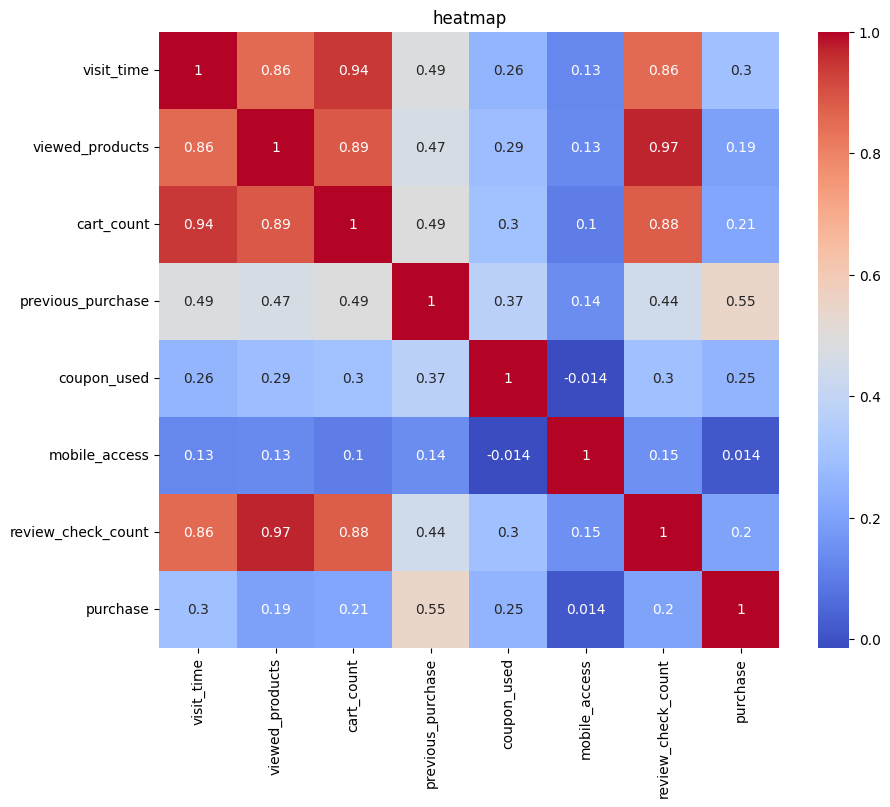

In [ ]:
# 변수간의 상관관계를 확인
corr = df2.corr()

plt.figure(figsize=(10,8))
sns.heatmap(
   corr,
   annot=True,
   cmap="coolwarm"     
)
plt.title("heatmap")
plt.show()

## purchase 피처에 영향을 주는 피처를 보기 

In [ ]:
# 상관계수(절대값)   해석              피처 선택 기준
# 0.00 - 0.19     거의 관계 없어...   제거 후보
# 0.20 - 0.39     약한 상관관계       참고용
# 0.40 - 0.59     중간 상관관계       사용고려
# 0.60 - 0.79     강한상관관계        중요한 피처 가능성 높다.**
# 0.80 - 1.0      매우 강한 관계..    의심.. 다중공선성 의심

# 단위를 낮춰서 본다면
#  > 0.3   의미가 있어..
#  > 0.9   제거를 해야 하나?